<center><font size="+4">ICT 2025/2026</font></center>
<center><font size="+2">Master of Science in Innovation Management – MAIN</font></center>
<center><font size="+2">Sant'Anna School of Advanced Studies, Pisa, Italy</font></center>
<center><img src="https://github.com/EMbeDS-education/ComputingDataAnalysisModeling20252026/raw/main/PDAI/jupyter/jupyterNotebooks/images/sssaLEMBEDSdtu.png" width="900" alt="L'EMbeDS"></center>

<center><font size="+2">Course responsible</font></center>
<center><font size="+2">Andrea Vandin a.vandin@santannapisa.it</font></center>

<center><font size="+2">co-Lecturer</font></center>
<center><font size="+2">Paolo Ferragina p.ferragina@santannapisa.it</font></center>
<center><font size="+2">co-Lecturer</font></center>
<center><font size="+2">Anna Monreale anna.monreale@unipi.it</font></center>

---

<center><font size="+4">Lecture 5: </font></center>
<center><font size="+2"> Creation of word clouds online news</font></center>
</center>

---

In [1]:
from IPython.display import Image, display
url_github_repo="https://github.com/EMbeDS-education/ComputingDataAnalysisModeling20252026/raw/main/ICT/"

# Computing and visulatizing the most important words in online news

This example shows that functions can hide a lot of complexity.
* E.g., we can download remote data by just invoking a function
* In particular, in this example we will:
    1. Download all the articles from the online service [NewsAPI](https://newsapi.org/)
         - An online service is like a function running on the internet...
    2. Combine the articles into one document (`str`)
    3. Clean data
    4. Compute word-frequency pairs
        - Word 'ciao' appears 3 times, word 'hello' appears 6 times ...
    5. Visualize the analysis in a Word Cloud
    
 

*Some definitions:*

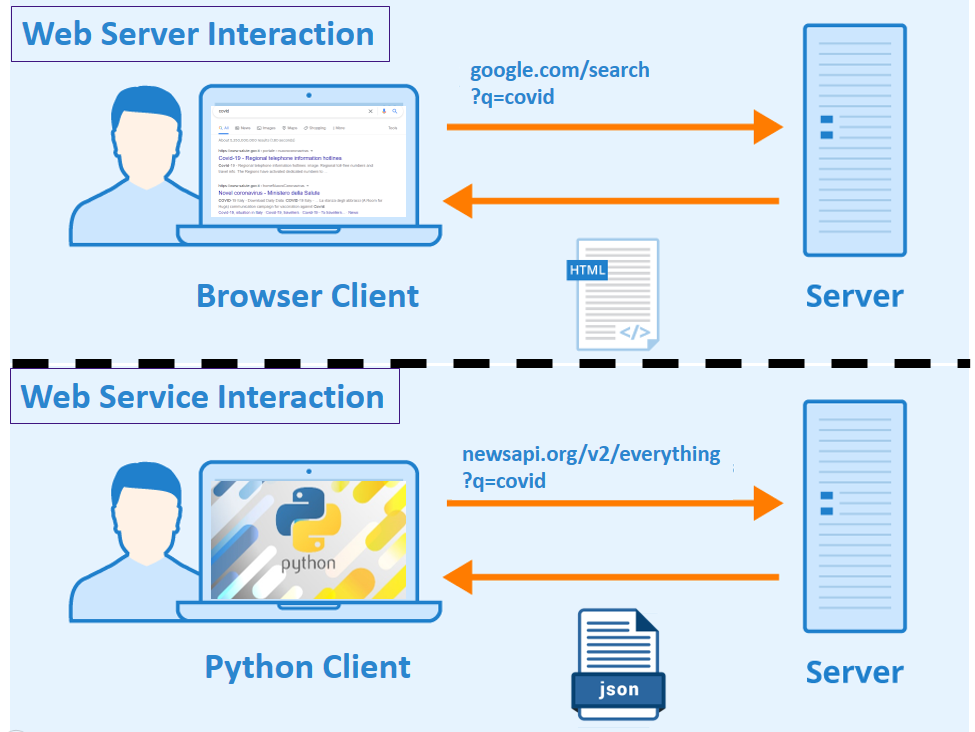

In [2]:
#from IPython.display import Image, display
#url_github_repo="https://github.com/EMbeDS-education/StatsAndComputing20232024/raw/main/PDAI/"
img=Image(url_github_repo+'jupyter/jupyterNotebooks/images/web_server_web_service.png',width=800)
display(img)

A **web service** is an application run by a web server (a remote computer connected to the interent). 
- The service can be called/invoked from some other computers connected to the internet 
- The service will _return_ data in a format that can't be sent over the internet
  - A little bit like a webpage, which is loaded from some remote server, and visualized in a browser
  - However, here data is not visualized but sent in a format that can be processed by programs.
  - Examples of used formats are XML (especially SOAP or so) or JSON.

An **Application Programming Interface (API)** allows two programs to communicate with one another. 
- An API defines the functions for one software program to interact with the other. 

This document has been __created by Daniele Licari__ and elaborated by Andrea Vandin.

# The modules we need to use

In [3]:
%pip install newsapi-python
%pip install wordcloud

  Using cached newsapi_python-0.2.7-py2.py3-none-any.whl.metadata (1.2 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached charset_normalizer-3.4.4-cp314-cp314-macosx_10_13_universal2.whl.metadata (37 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
Using cached newsapi_python-0.2.7-py2.py3-none-any.whl (7.9 kB)
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached charset_normalizer-3.4.4-cp314-cp314-macosx_10_13_universal2.whl (207 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [newsapi-python]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
#We might also get some errors like 'Only supported for TrueType fonts'
#We can fix them running these installations

%pip install --upgrade pip 
%pip install --upgrade Pillow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
# integrating News API into your Python application 
from newsapi import NewsApiClient 

# creating wordclouds into your Python application 
from wordcloud import WordCloud, STOPWORDS

#  In Python, string.punctuation will give the sets of all punctuations. 
import string

import matplotlib.pyplot as plt

In [6]:
STOPWORDS

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

__NewsApiClient__ is a local client for the online service [__NewsAPI__](https://newsapi.org/) that allows you to get news from [eveywhere in the world](https://newsapi.org/sources)
* Intuitively, an online service is like an online function running in a remote server (computer)
* A local client is a piece of code runnning in your machine that communicates with the online service
  * It allows you to easily interact with the online service
  * The interaction is typically done through a set of message exchanges as prescribed by the APIs of the service
* We need a `api_key` that is a univoque identifier 
  * necessary when making requests to be identified
  * __can be obtained registering [here](https://newsapi.org/register)__

There exist many online services accessible with Python (e.g. [Twitter API](https://www.tweepy.org/))
* Most of them follow this api-key approach
* E.g. to enforce subscriptions
<!-- * In our case, __we are using a free subscription that allows us to only get the first 250 characters from a news item__ -->

# Data loading

We first get the most relevant articles (top 100) about coronavirus, published in usa-today
* This looks like a [normal function invocation](https://newsapi.org/docs/client-libraries/python)
* But under the hood a lot happens to contact the remote service 
(https://newsapi.org/v2/everything?q=coronavirus&sources=usa-today&language=en&pageSize=100&sortBy=relevancy&apiKey=1f6979fc955b465f9b076310217a19a3)

Luckily, the function `get_everything` hides this complexity to us

In [7]:
#
#Guide from:
# https://newsapi.org/docs/client-libraries/python
#

# from newsapi import NewsApiClient

# # Init
# newsapi = NewsApiClient(api_key='1f6979fc955b465f9b076310217a19a3')

# # /v2/top-headlines
# top_headlines = newsapi.get_top_headlines(q='bitcoin',
#                                           sources='bbc-news,the-verge',
#                                           category='business',
#                                           language='en',
#                                           country='us')

# # /v2/everything
# all_articles = newsapi.get_everything(q='bitcoin',
#                                       sources='bbc-news,the-verge',
#                                       domains='bbc.co.uk,techcrunch.com',
#                                       #from_param='2017-12-01',
#                                       #to='2017-12-12',
#                                       language='en',
#                                       sort_by='relevancy',
#                                       page=2)

# # /v2/top-headlines/sources
# #sources = newsapi.get_sources()

In [8]:
my_api_key='1f6979fc955b465f9b076310217a19a3'
#newsapi = NewsApiClient(api_key='345f8a0aa8c64d549fde1d8343d036f8')
newsapi = NewsApiClient(api_key=my_api_key)
json_data = newsapi.get_everything(
                                    #q='coronavirus',        # All the articles that contain this word
                                    q='covid',
                                    #q='hamas',              # All the articles that contain this word
                                    language='en',
                                    #sources = 'usa-today', # The newspaper of interest
                                    sources = 'cnn', # The newspaper of interest
                                    #sources = 'bbc-news', # The newspaper of interest
                                    #sources = 'bbc-news,the-verge'
                                    #
                                    page_size=100,           # Get 100 articles
                                    sort_by='relevancy'
                                    )
#There exist many more parameters allowing us the ask for more articles, different sources, etc

#print(json_data)

In [9]:
json_data

{'status': 'ok',
 'totalResults': 14,
 'articles': [{'source': {'id': 'cnn', 'name': 'CNN'},
   'author': 'Meg Tirrell',
   'title': 'FDA refuses to review Moderna’s application for mRNA flu vaccine, company says | CNN',
   'description': 'The US Food and Drug Administration has refused to accept an application from Moderna to review its first mRNA seasonal flu vaccine, the company said Tuesday, in another setback for the technology that’s been a target of some Trump administration health offic…',
   'url': 'https://www.cnn.com/2026/02/10/health/fda-moderna-mrna-flu-vaccine',
   'urlToImage': 'https://media.cnn.com/api/v1/images/stellar/prod/c-gettyimages-2235743716.jpg?c=16x9&q=w_800,c_fill',
   'publishedAt': '2026-02-10T23:14:18Z',
   'content': 'The US Food and Drug Administration has refused to accept an application from Moderna to review its first mRNA seasonal flu vaccine, the company said Tuesday, in another setback for the technology th… [+2324 chars]'},
  {'source': {'id': 'c

In [10]:
json_data['articles']
#json_data['status']

[{'source': {'id': 'cnn', 'name': 'CNN'},
  'author': 'Meg Tirrell',
  'title': 'FDA refuses to review Moderna’s application for mRNA flu vaccine, company says | CNN',
  'description': 'The US Food and Drug Administration has refused to accept an application from Moderna to review its first mRNA seasonal flu vaccine, the company said Tuesday, in another setback for the technology that’s been a target of some Trump administration health offic…',
  'url': 'https://www.cnn.com/2026/02/10/health/fda-moderna-mrna-flu-vaccine',
  'urlToImage': 'https://media.cnn.com/api/v1/images/stellar/prod/c-gettyimages-2235743716.jpg?c=16x9&q=w_800,c_fill',
  'publishedAt': '2026-02-10T23:14:18Z',
  'content': 'The US Food and Drug Administration has refused to accept an application from Moderna to review its first mRNA seasonal flu vaccine, the company said Tuesday, in another setback for the technology th… [+2324 chars]'},
 {'source': {'id': 'cnn', 'name': 'CNN'},
  'author': 'Catherine Nicholls, Sophi

The return value `json_data` is just a dictionary collecting information about the remote request

In [11]:
print(type(json_data))
print()
print(json_data.keys())
print()
print('The status of the request is',json_data['status'],'There are ',json_data['totalResults'],'articles matching the request.')
print('We got',len(json_data['articles']),'articles')
print()

<class 'dict'>

dict_keys(['status', 'totalResults', 'articles'])

The status of the request is ok There are  14 articles matching the request.
We got 14 articles



In [12]:
articles = json_data['articles']

print(type(articles))
print(type(articles[0]))
print(articles[0].keys())

<class 'list'>
<class 'dict'>
dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content'])


In [13]:
first_article=articles[0]
first_article

{'source': {'id': 'cnn', 'name': 'CNN'},
 'author': 'Meg Tirrell',
 'title': 'FDA refuses to review Moderna’s application for mRNA flu vaccine, company says | CNN',
 'description': 'The US Food and Drug Administration has refused to accept an application from Moderna to review its first mRNA seasonal flu vaccine, the company said Tuesday, in another setback for the technology that’s been a target of some Trump administration health offic…',
 'url': 'https://www.cnn.com/2026/02/10/health/fda-moderna-mrna-flu-vaccine',
 'urlToImage': 'https://media.cnn.com/api/v1/images/stellar/prod/c-gettyimages-2235743716.jpg?c=16x9&q=w_800,c_fill',
 'publishedAt': '2026-02-10T23:14:18Z',
 'content': 'The US Food and Drug Administration has refused to accept an application from Moderna to review its first mRNA seasonal flu vaccine, the company said Tuesday, in another setback for the technology th… [+2324 chars]'}

We can ignore all the metadata (i.e. the data about the remote request) and focus on the actual articles only

In [14]:
#Get the description of the first article
content = articles[0]['description']
print('The content is long',len(content),"characters")
print()
print('The content:')
print(content)

The content is long 260 characters

The content:
The US Food and Drug Administration has refused to accept an application from Moderna to review its first mRNA seasonal flu vaccine, the company said Tuesday, in another setback for the technology that’s been a target of some Trump administration health offic…


Now let's combine the content of all the news into variable `contents`

In [15]:
def combine_articles(list_of_articles):
    contents = ''
    for article in list_of_articles:
         #  check if key 'description' has Non-None value in dictionary 
        if article['description']:
            contents += article['description']+" "
            
    return contents

contents = combine_articles(articles)
print('Overall we have',len(contents),'characters')
contents

Overall we have 2877 characters


'The US Food and Drug Administration has refused to accept an application from Moderna to review its first mRNA seasonal flu vaccine, the company said Tuesday, in another setback for the technology that’s been a target of some Trump administration health offic… US President Donald Trump crossed “a very dangerous red line” after Iran’s supreme leader Ali Khamenei was killed in US-Israeli strikes, an Iranian official told CNN. Follow for live updates President Donald Trump said Saturday that he is sending a hospital boat to Greenland, the Arctic island and Danish territory he has sought to acquire. The Trump administration is releasing more than $5 billion in long-delayed disaster aid to states – but not to several Democrat-led states where President Trump has clashed with the governors, according to four sources familiar with the plan. The director of the National Institutes of Health, Dr. Jay Bhattacharya, will also take on the temporary role of acting director of the US Centers for Di

# Data cleaning, manipulation and visualization 

## Implementing two functions for data cleaning

__Stop words__ are usually the most common words in any text ( like “the”, “of”, “to” and “and”), 
* They don’t tell us much about the actual content in a text
* These are the words we want to ignore - this is our data cleaning

We want to find the words that will help us differentiate a text from texts that are about different subjects. 
* __We will filter out the common words__.
* Of course, we are going to use a function for doing this

Furthermore, we want to ignore punctuation 
* In Python, string.punctuation will give the all sets of punctuation.
* We are going to use it to delete all punctuation from a string

In [16]:
STOPWORDS

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

In [17]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [18]:
# to remove STOPWORDS from a list of strings
def remove_stopwords(wordlist):
    return [ w for w in wordlist if w not in STOPWORDS ]

# to remove Punctuations from a string
def remove_punctuations(my_str): 
    no_punct = ""
    for char in my_str:
        if char  not in string.punctuation:
            no_punct = no_punct + char
    return no_punct

In [19]:
# for testing 
remove_punctuations('Andrea likes pizza and Python!! and,,,,, you? . ' + "ciao")

'Andrea likes pizza and Python and you  ciao'

In [20]:
no_punct=remove_punctuations('Andrea likes pizza and Python!! and you? . ' + "ciao")
print(no_punct)
no_punct.split()

Andrea likes pizza and Python and you  ciao


['Andrea', 'likes', 'pizza', 'and', 'Python', 'and', 'you', 'ciao']

In [21]:
clean_str=remove_punctuations('Andrea likes pizza and Python!! and you? . ' + "ciao")
print(clean_str)

clean_str.split()

Andrea likes pizza and Python and you  ciao


['Andrea', 'likes', 'pizza', 'and', 'Python', 'and', 'you', 'ciao']

In [22]:
remove_stopwords(
    remove_punctuations('Andrea likes pizza and Python!! and you? . ' + "ciao").split()
    )

['Andrea', 'likes', 'pizza', 'Python', 'ciao']

## Actual cleaning, manipulation, visualization

Now begins the funny part
1. Let's clean the data removing not interesting words
2. Let's compute the frequency of use of words
3. Let's visualize graphically the computed analysis - Word Cloud

In [23]:
#contents

In [24]:
# 1 cleaning data
def clean_data(content_to_clean):
    print('Before cleaning')
    print(content_to_clean[:200])
    print()
    # simple text normalization: string in lower case
    content_to_clean = content_to_clean.lower()
    # remove punctuations
    cleaned_content = remove_punctuations(content_to_clean)
    # remove stopwords
    #   split the string in a list of words
    cleaned_content_words = cleaned_content.split()
    #   remove stop_words
    cleaned_content_words = remove_stopwords(cleaned_content_words)
    print('After cleaning')
    print(cleaned_content_words[:200])
    print()
    return cleaned_content_words

cleaned_content = clean_data(contents)
#cleaned_content

Before cleaning
The US Food and Drug Administration has refused to accept an application from Moderna to review its first mRNA seasonal flu vaccine, the company said Tuesday, in another setback for the technology tha

After cleaning
['us', 'food', 'drug', 'administration', 'refused', 'accept', 'application', 'moderna', 'review', 'first', 'mrna', 'seasonal', 'flu', 'vaccine', 'company', 'said', 'tuesday', 'another', 'setback', 'technology', 'that’s', 'target', 'trump', 'administration', 'health', 'offic…', 'us', 'president', 'donald', 'trump', 'crossed', '“a', 'dangerous', 'red', 'line”', 'iran’s', 'supreme', 'leader', 'ali', 'khamenei', 'killed', 'usisraeli', 'strikes', 'iranian', 'official', 'told', 'cnn', 'follow', 'live', 'updates', 'president', 'donald', 'trump', 'said', 'saturday', 'sending', 'hospital', 'boat', 'greenland', 'arctic', 'island', 'danish', 'territory', 'sought', 'acquire', 'trump', 'administration', 'releasing', '5', 'billion', 'longdelayed', 'disaster', 'aid', 'sta

In [25]:
# 2 computing word-frequency pairs
def analyze_data(cleaned_content):
    wordcount = {}
    for w in cleaned_content:
        if w in wordcount:
            #wordcount[w] += 1
            wordcount[w] = wordcount[w] + 1
        else:
            wordcount[w] = 1
    return wordcount

#wordcount = analyze_data(['ciao','ciao','andrea'])
wordcount = analyze_data(cleaned_content)
wordcount

{'us': 4,
 'food': 1,
 'drug': 1,
 'administration': 5,
 'refused': 1,
 'accept': 1,
 'application': 1,
 'moderna': 1,
 'review': 1,
 'first': 2,
 'mrna': 1,
 'seasonal': 1,
 'flu': 1,
 'vaccine': 1,
 'company': 1,
 'said': 2,
 'tuesday': 1,
 'another': 2,
 'setback': 1,
 'technology': 1,
 'that’s': 1,
 'target': 1,
 'trump': 8,
 'health': 6,
 'offic…': 1,
 'president': 5,
 'donald': 4,
 'crossed': 2,
 '“a': 1,
 'dangerous': 1,
 'red': 1,
 'line”': 1,
 'iran’s': 1,
 'supreme': 1,
 'leader': 2,
 'ali': 1,
 'khamenei': 1,
 'killed': 1,
 'usisraeli': 1,
 'strikes': 1,
 'iranian': 1,
 'official': 2,
 'told': 3,
 'cnn': 5,
 'follow': 1,
 'live': 1,
 'updates': 1,
 'saturday': 1,
 'sending': 1,
 'hospital': 1,
 'boat': 1,
 'greenland': 1,
 'arctic': 1,
 'island': 1,
 'danish': 1,
 'territory': 1,
 'sought': 1,
 'acquire': 1,
 'releasing': 1,
 '5': 1,
 'billion': 1,
 'longdelayed': 1,
 'disaster': 1,
 'aid': 1,
 'states': 2,
 '–': 3,
 'several': 1,
 'democratled': 1,
 'clashed': 1,
 'governor

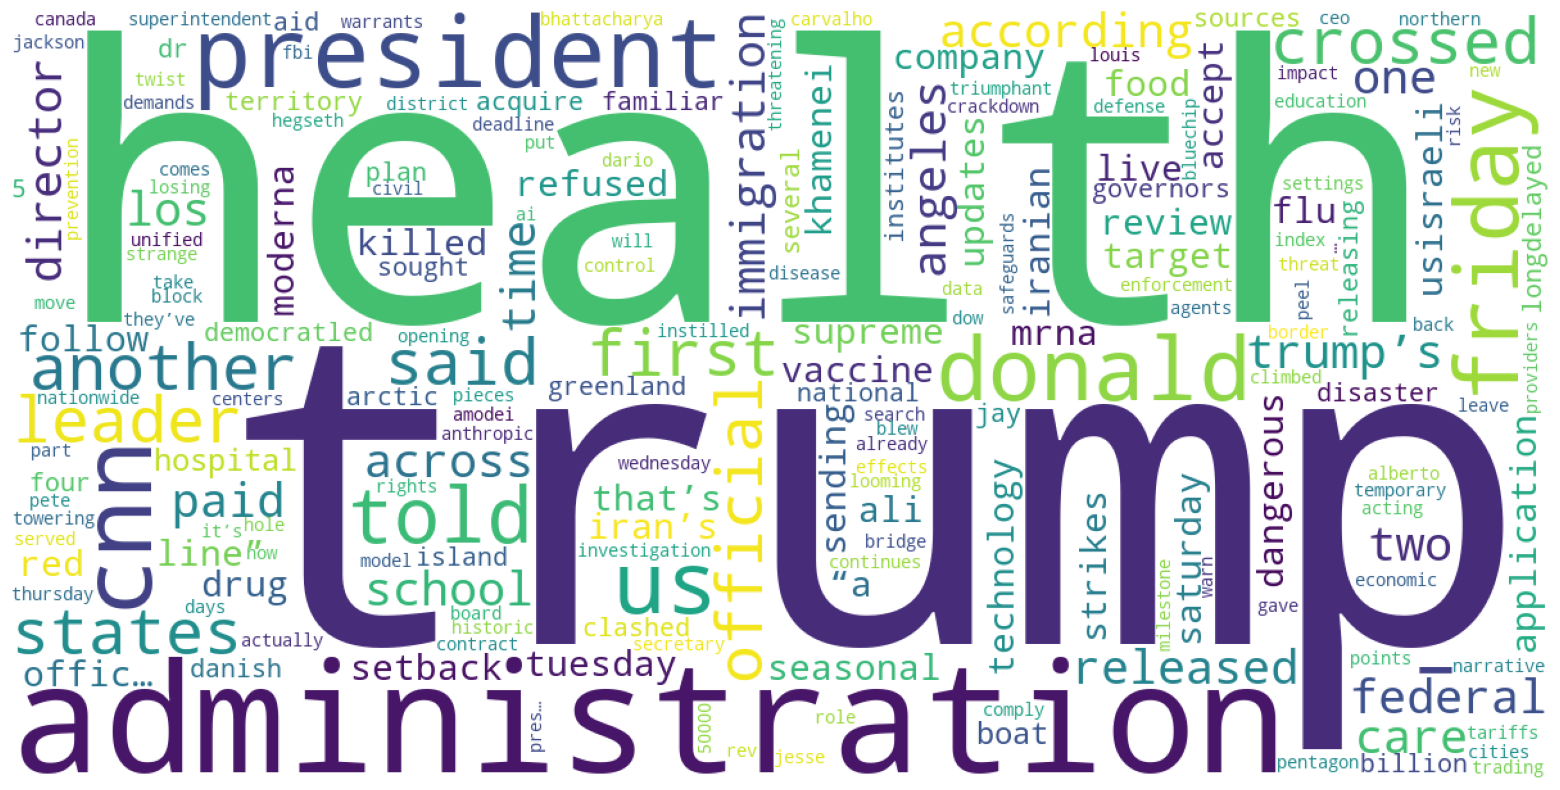

In [26]:
# 3 visualizing the analysisis in a Word Cloud
def visualize_data(wordcount):
    wordCloudMaker=WordCloud(width=1200,height=600, background_color='white')
    wc = wordCloudMaker.generate_from_frequencies(wordcount)
    plt.figure(figsize=(20,10))
    plt.imshow(wc)
    plt.axis("off")
    plt.show()

visualize_data(wordcount)

# Let's put everything in a function, so that we can run it easily for different sources

In [27]:
def make_world_cloud(query,source,n_articles=50):
    """
    Download relevant 'n_article' articles that contain 'query' from 'source' newspaper using NewsAPI
    and plot a wordcloud with the most common words in the corpus.
    :param query: 
        Keywords or phrases to search for in the article title and body.
    :param source: 
        the news source or blog you want headlines from
    :param n_articles:
        The number of articles to return (maximum 100)
    """
    # 1.  Download all the articles the online service NewsAPI
    newsapi = NewsApiClient(api_key=my_api_key)
    json_data = newsapi.get_everything(q=query,           # All the articles that contain this word
                                       language='en',
                                       sources=source,      # The newspaper of interest
                                       page_size=n_articles,  # Get 50 articles (by default)
                                       sort_by='relevancy'
                                    )
    
    # 2. Combine the articles into one document (string)
    contents = combine_articles(json_data['articles'])
    
    # 3. cleaning data
    cleaned_content = clean_data(contents)

    # 4. computing word-frequency pairs
    wordcount = analyze_data(cleaned_content)
 
    # 5. Visualizing the analysis in a Word Cloud
    visualize_data(wordcount)

In [28]:
help(make_world_cloud)

Help on function make_world_cloud in module __main__:

make_world_cloud(query, source, n_articles=50)
    Download relevant 'n_article' articles that contain 'query' from 'source' newspaper using NewsAPI
    and plot a wordcloud with the most common words in the corpus.
    :param query:
        Keywords or phrases to search for in the article title and body.
    :param source:
        the news source or blog you want headlines from
    :param n_articles:
        The number of articles to return (maximum 100)



Before cleaning
President Donald Trump placed a huge wager by launching a massive air assault on Iran despite having done little to prepare Americans for a new Middle East war with immense risks and years of future c

After cleaning
['president', 'donald', 'trump', 'placed', 'huge', 'wager', 'launching', 'massive', 'air', 'assault', 'iran', 'despite', 'done', 'little', 'prepare', 'americans', 'new', 'middle', 'east', 'war', 'immense', 'risks', 'years', 'future', 'consequences', 'reported', 'death', 'iranian', 'supreme', 'lead…', 'steve', 'witkoff', 'jared', 'kushner', 'running', 'president', 'donald', 'trump’s', 'freelance', 'peacekeeping', 'franchise', 'global', 'stability', 'countless', 'lives', 'boss’s', 'best', 'hope', 'elusive', 'nobel', 'peace', 'prize', 'depend', 'pope', 'leo', 'xiv', 'will', 'joining', 'us', 'president', 'donald', 'trump’s', '“board', 'peace”', 'vatican’s', 'top', 'diplomat', 'said', 'tuesday', 'adding', 'united', 'nations', 'left', 'handle', 'crisis', 'situati

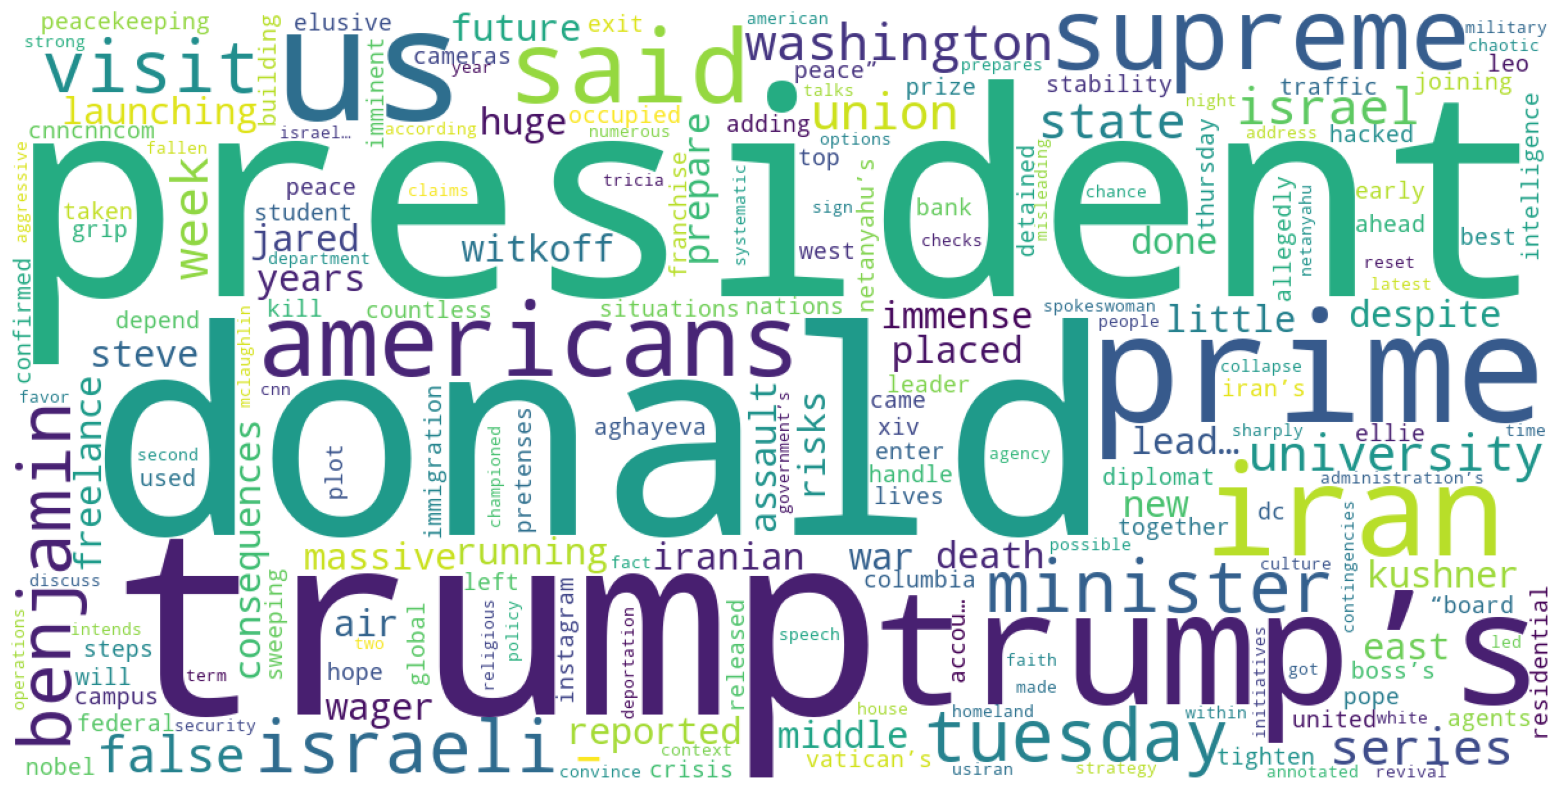

In [29]:
#make_world_cloud('coronavirus','the-verge',100)
make_world_cloud('hamas','cnn',100)

Before cleaning
Andrew Mountbatten-Windsor is in custody over his links to the late Jeffrey Epstein Wahat al-Salam/Neve Shalom is a unique community located on a hilltop between Jerusalem and Tel Aviv, where Jewish a

After cleaning
['andrew', 'mountbattenwindsor', 'custody', 'links', 'late', 'jeffrey', 'epstein', 'wahat', 'alsalamneve', 'shalom', 'unique', 'community', 'located', 'hilltop', 'jerusalem', 'tel', 'aviv', 'jewish', 'palestinian', 'families', 'lived', 'together', 'late', '1970s', 'journalist', 'mike', 'lanchin', 'first', 'visited', 'community', 'early', '1980s', 't…', 'andrew', 'mountbattenwindsor', 'brother', 'king', 'charles', 'iii', 'arrested', 'suspicion', 'misconduct', 'public', 'office', 'king', 'charles', 'said', 'law', 'must', 'take', 'course', 'response', 'andrews', 'arrest', 'police', '‘full', 'wholehearted', 'su…', 'palestinian', 'red', 'crescent', 'say', 'strike', 'tent', 'encampment', 'northern', 'gaza', 'killed', 'least', 'six', 'people', 'strikes', 'among', 

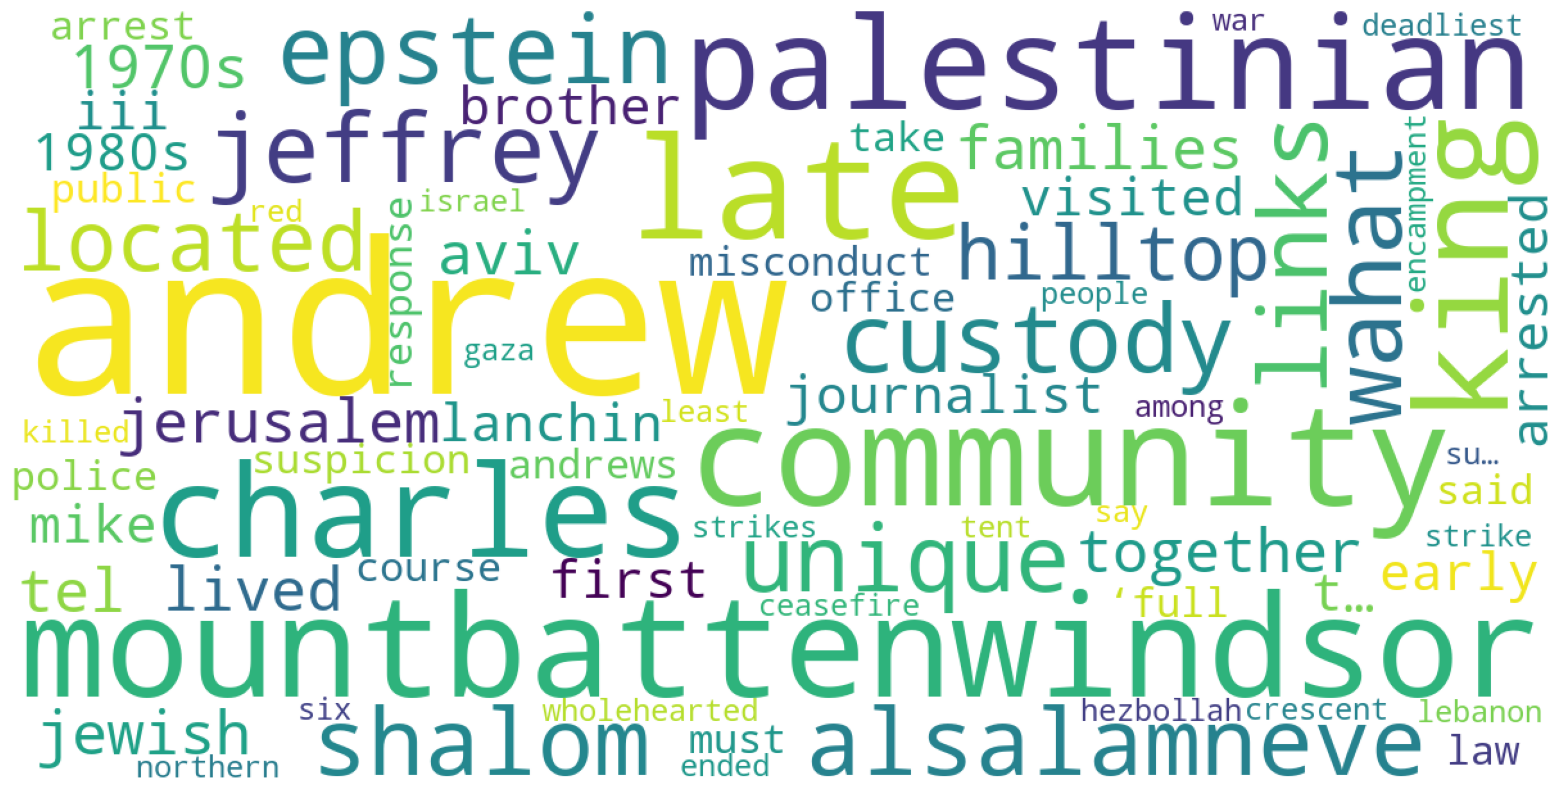

In [30]:
make_world_cloud('hamas','bbc-news',100)

Before cleaning
Here's the time difference between Italy and the United States. The 2026 Milano Cortina Olympic Games continue on Feb. 6. Here are all the events taking place today in Italy. The 2026 Milano Cortina O

After cleaning
['heres', 'time', 'difference', 'italy', 'united', 'states', '2026', 'milano', 'cortina', 'olympic', 'games', 'continue', 'feb', '6', 'events', 'taking', 'place', 'today', 'italy', '2026', 'milano', 'cortina', 'olympic', 'games', 'continue', 'feb', '7', 'events', 'taking', 'place', 'today', 'italy', 'canada', 'defending', 'olympic', 'champ', 'womens', 'hockey', 'beating', 'team', 'usa', 'four', 'years', 'ago', 'beijing', 'americans', 'avenge', 'loss', 'italy', 'vice', 'president', 'jd', 'vance', 'head', 'us', 'delegation', '2026', 'winter', 'olympics', 'italy', 'tells', 'athletes', 'everybody', 'rooting', 'guys', 'snowboardings', 'ollie', 'martin', 'arrives', 'italy', '2026', 'olympics', 'medal', 'hopeful', '17', 'age', 'teammate', 'red', 'gerard', 'won', '

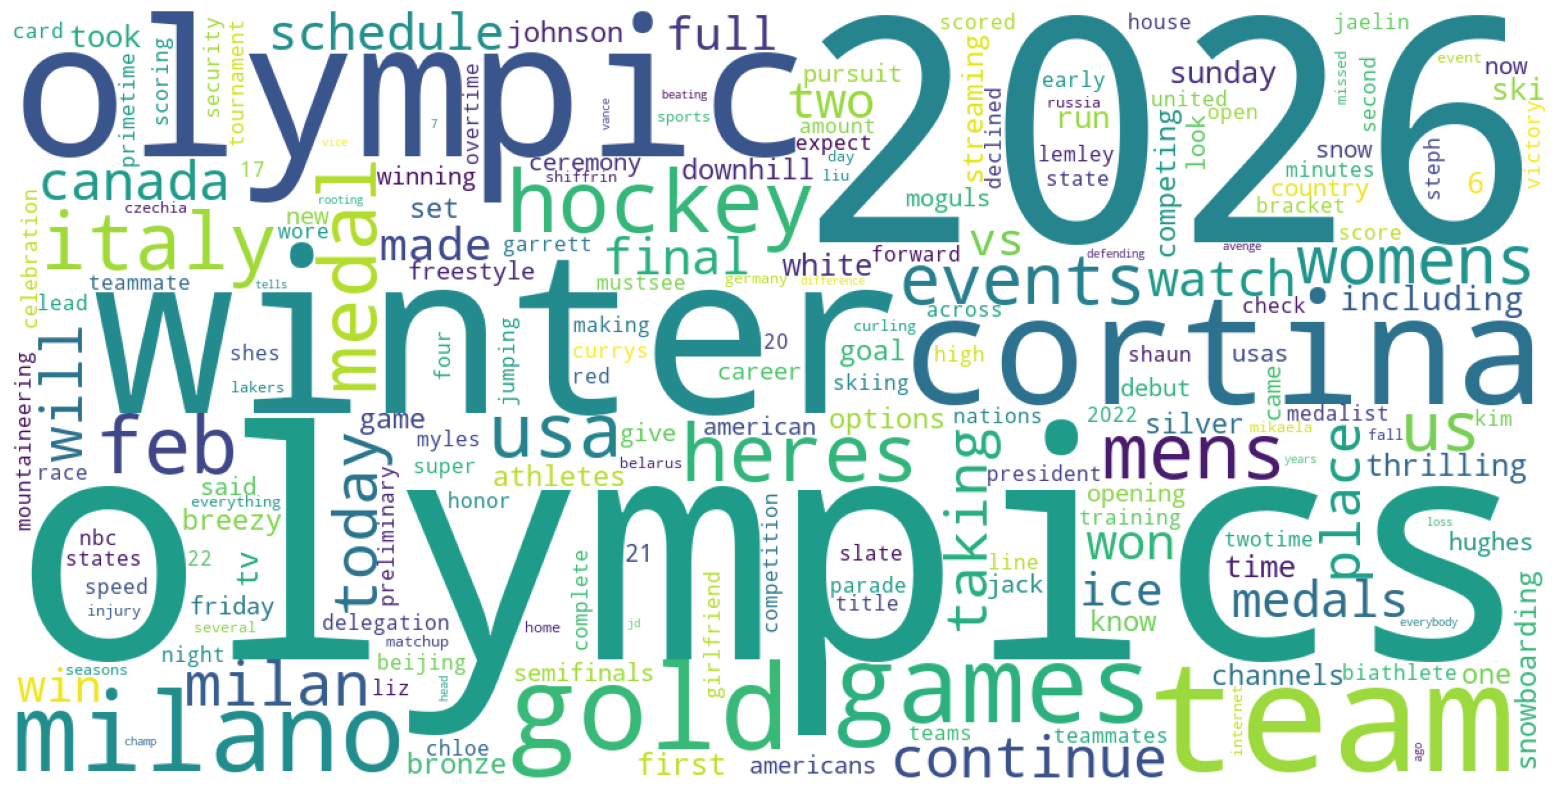

In [31]:
make_world_cloud("italy",'usa-today',100)

Before cleaning
Andrew Mountbatten-Windsor is in custody over his links to the late Jeffrey Epstein Wahat al-Salam/Neve Shalom is a unique community located on a hilltop between Jerusalem and Tel Aviv, where Jewish a

After cleaning
['andrew', 'mountbattenwindsor', 'custody', 'links', 'late', 'jeffrey', 'epstein', 'wahat', 'alsalamneve', 'shalom', 'unique', 'community', 'located', 'hilltop', 'jerusalem', 'tel', 'aviv', 'jewish', 'palestinian', 'families', 'lived', 'together', 'late', '1970s', 'journalist', 'mike', 'lanchin', 'first', 'visited', 'community', 'early', '1980s', 't…', 'andrew', 'mountbattenwindsor', 'brother', 'king', 'charles', 'iii', 'arrested', 'suspicion', 'misconduct', 'public', 'office', 'king', 'charles', 'said', 'law', 'must', 'take', 'course', 'response', 'andrews', 'arrest', 'police', '‘full', 'wholehearted', 'su…', 'president', 'donald', 'trump', 'placed', 'huge', 'wager', 'launching', 'massive', 'air', 'assault', 'iran', 'despite', 'done', 'little', 'prepare', 

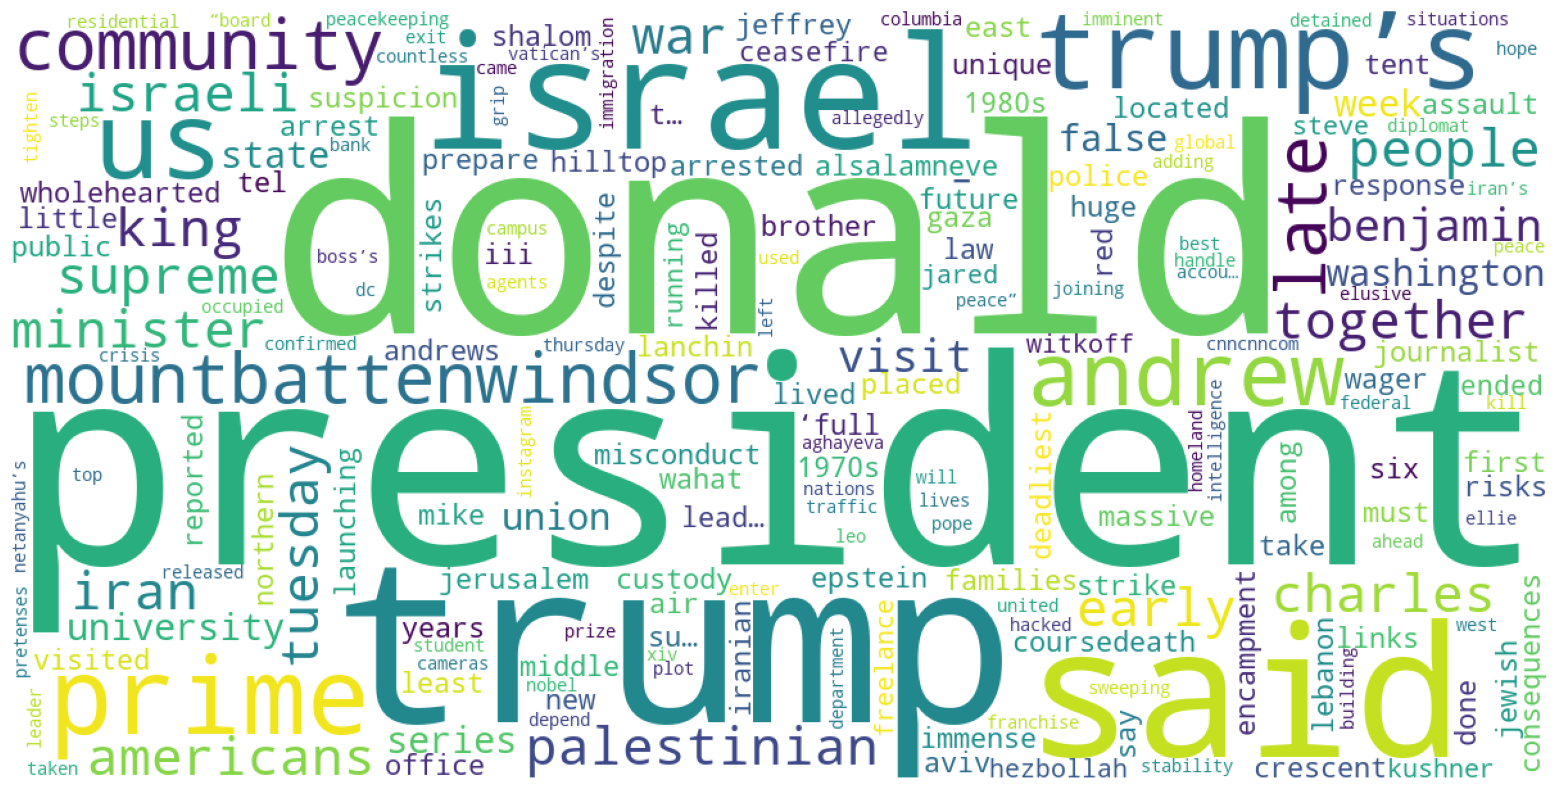

In [32]:
make_world_cloud('hamas','cnn,bbc-news',100)

Before cleaning
Andrew Mountbatten-Windsor is in custody over his links to the late Jeffrey Epstein Wahat al-Salam/Neve Shalom is a unique community located on a hilltop between Jerusalem and Tel Aviv, where Jewish a

After cleaning
['andrew', 'mountbattenwindsor', 'custody', 'links', 'late', 'jeffrey', 'epstein', 'wahat', 'alsalamneve', 'shalom', 'unique', 'community', 'located', 'hilltop', 'jerusalem', 'tel', 'aviv', 'jewish', 'palestinian', 'families', 'lived', 'together', 'late', '1970s', 'journalist', 'mike', 'lanchin', 'first', 'visited', 'community', 'early', '1980s', 't…', 'andrew', 'mountbattenwindsor', 'brother', 'king', 'charles', 'iii', 'arrested', 'suspicion', 'misconduct', 'public', 'office', 'king', 'charles', 'said', 'law', 'must', 'take', 'course', 'response', 'andrews', 'arrest', 'police', '‘full', 'wholehearted', 'su…', 'palestinian', 'red', 'crescent', 'say', 'strike', 'tent', 'encampment', 'northern', 'gaza', 'killed', 'least', 'six', 'people', 'strikes', 'among', 

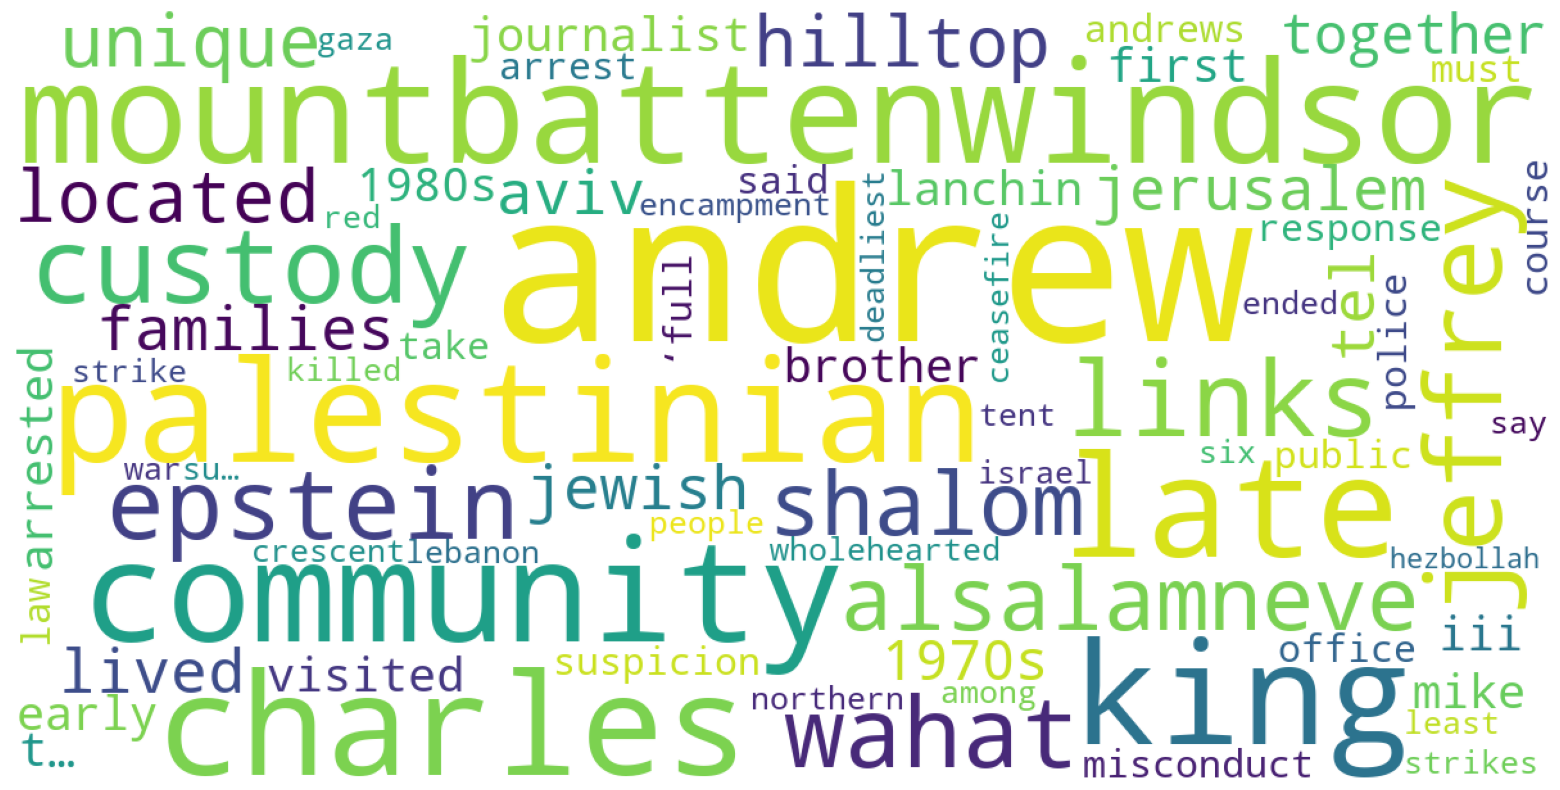

In [33]:
#make_world_cloud('hamas','ars-technica',100)
#make_world_cloud('geopolitics','bbc-news',100)
make_world_cloud('hamas','bbc-news',100)
#make_world_cloud('covid','cnn',100)